<a href="https://colab.research.google.com/github/raflyalvish-id/Take-Home-Test-Rafly/blob/main/Take_Home_Test_Rafly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Set Up Environment

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

path_file = '/content/drive/MyDrive/Dibimbing/THT/Dataset/Zomato Dataset.csv'

# Load dataset
df = pd.read_csv(path_file)

# Menampilkan info kolom dan tipe data
print("--- INFO DATASET ---")
df.info()

# Menampilkan 5 data teratas
print("\n--- 5 DATA TERATAS ---")
df.head()

Mounted at /content/drive
--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density       

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


ditemukan missing value di kolom Delivery_person_Age, Delivery_person_Ratings, Weather_conditions, Road_traffic_density, dan City                         



#Cleanning Data

In [ ]:
import numpy as np

# 1. Menangani Missing Values
# Untuk kolom numerik seperti Age dan Ratings, diisi dengan median agar tidak terpengaruh outlier
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].median())

# Untuk kolom kategorikal, diisi dengan 'Unknown' atau modus (nilai terbanyak)
df['Weather_conditions'] = df['Weather_conditions'].fillna('Unknown')
df['Road_traffic_density'] = df['Road_traffic_density'].fillna('Unknown')
df['Festival'] = df['Festival'].fillna('No')
df['City'] = df['City'].fillna('Unknown')
df['Time_Orderd'] = df['Time_Orderd'].fillna('Unknown')

# 2. Feature Engineering: Menghitung Jarak Geografis (Haversine Formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    # Mengubah derajat ke radian
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Rumus Haversine
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c # Radius bumi dalam kilometer
    return km

# Membuat kolom baru 'distance_km'
df['distance_km'] = haversine_distance(
    df['Restaurant_latitude'], df['Restaurant_longitude'],
    df['Delivery_location_latitude'], df['Delivery_location_longitude']
)

# 3. Merapikan format tanggal
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

# Cek kembali dataset setelah dibersihkan
print("--- Sisa Missing Values ---")
print(df.isnull().sum())
print("\n--- Tampilan Data Setelah Cleaning ---")
df[['ID', 'distance_km', 'Time_taken (min)']].head()

--- Sisa Missing Values ---
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
dtype: int64

--- Tampilan Data Setelah Cleaning ---


,ID,distance_km,Time_taken (min)
0,0xcdcd,10.274127,46
1,0xd987,6.238399,23
2,0x2784,13.779204,21
3,0xc8b6,2.928418,20
4,0xdb64,19.384440,41


In [ ]:
# 1. Menghitung total baris yang duplikat (jika ada)
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat secara keseluruhan: {duplicate_count}")

# 2. Menghitung duplikat khusus berdasarkan ID pesanan (karena ID harus unik)
id_duplicate_count = df.duplicated(subset=['ID']).sum()
print(f"Jumlah ID pesanan yang duplikat: {id_duplicate_count}")

# 3. Jika ada duplikat, kita hapus dan pertahankan data pertama
if duplicate_count > 0 or id_duplicate_count > 0:
    df = df.drop_duplicates(subset=['ID'], keep='first')
    print("Data duplikat telah berhasil dihapus!")
else:
    print("Aman! Tidak ada data duplikat di dataset ini.")

Jumlah data duplikat secara keseluruhan: 0
Jumlah ID pesanan yang duplikat: 0
Aman! Tidak ada data duplikat di dataset ini.


#EDA

--- STATISTIK DESKRIPTIF ---
       Time_taken (min)   distance_km  Delivery_person_Age  \
count      45584.000000  45584.000000         45584.000000   
mean          26.293963     99.258962            29.584525   
std            9.384298   1099.148610             5.696221   
min           10.000000      1.464148            15.000000   
25%           19.000000      4.660565            25.000000   
50%           26.000000      9.258540            30.000000   
75%           32.000000     13.755336            34.000000   
max           54.000000  19680.310661            50.000000   

       Delivery_person_Ratings  
count             45584.000000  
mean                  4.636546  
std                   0.327931  
min                   1.000000  
25%                   4.600000  
50%                   4.700000  
75%                   4.800000  
max                   6.000000  


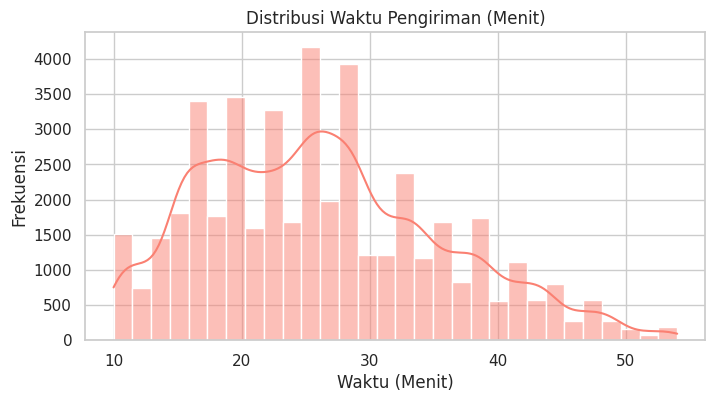

/tmp/ipykernel_1546/3802861315.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df, palette='Set2')


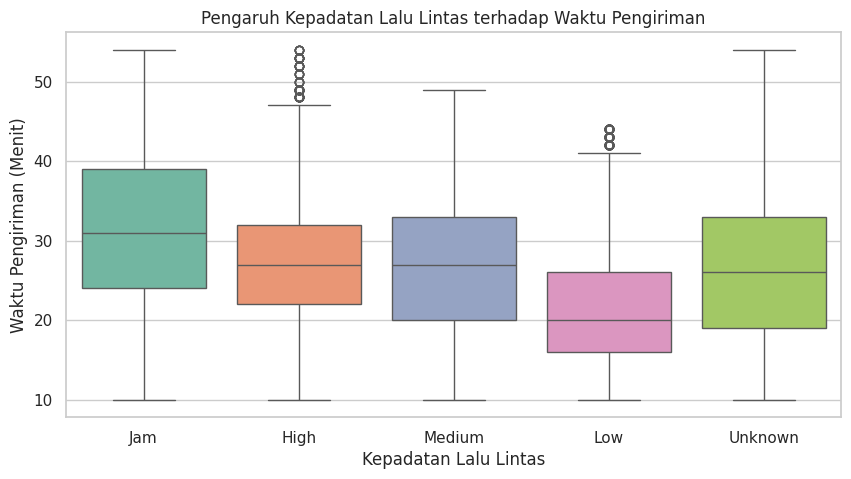

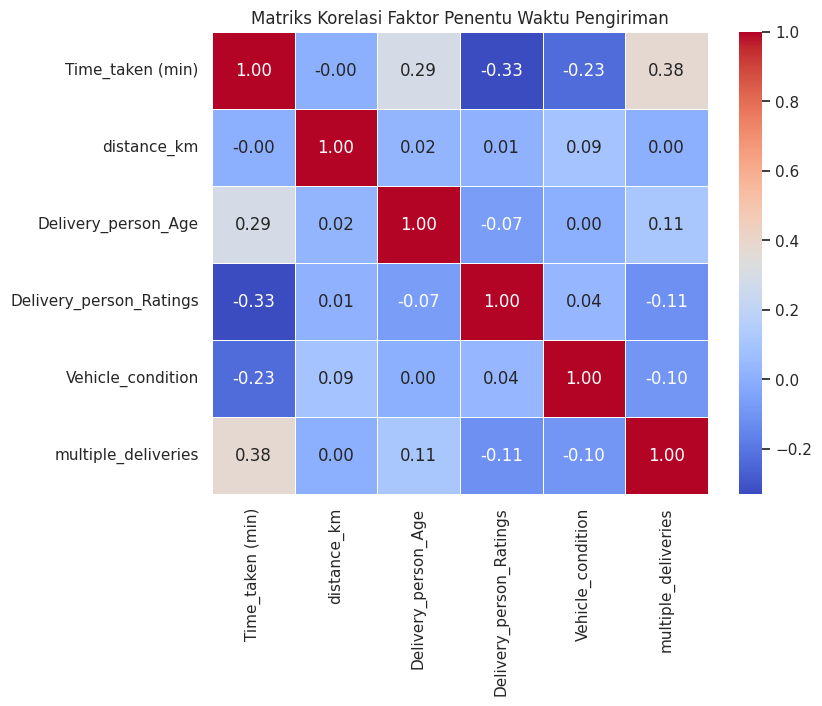

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="whitegrid")

# 1. Statistik Deskriptif Variabel Target dan Jarak
print("--- STATISTIK DESKRIPTIF ---")
print(df[['Time_taken (min)', 'distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings']].describe())

# 2. Visualisasi 1: Distribusi Waktu Pengiriman (Target Variabel)
plt.figure(figsize=(8, 4))
sns.histplot(df['Time_taken (min)'], bins=30, kde=True, color='salmon')
plt.title('Distribusi Waktu Pengiriman (Menit)')
plt.xlabel('Waktu (Menit)')
plt.ylabel('Frekuensi')
plt.show()

# 3. Visualisasi 2: Hubungan antara Kepadatan Lalu Lintas dan Waktu Pengiriman
plt.figure(figsize=(10, 5))
sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df, palette='Set2')
plt.title('Pengaruh Kepadatan Lalu Lintas terhadap Waktu Pengiriman')
plt.xlabel('Kepadatan Lalu Lintas')
plt.ylabel('Waktu Pengiriman (Menit)')
plt.show()

# 4. Visualisasi 3: Analisis Korelasi (Heatmap) untuk Variabel Numerik
plt.figure(figsize=(8, 6))
numerical_cols = ['Time_taken (min)', 'distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries']
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Faktor Penentu Waktu Pengiriman')
plt.show()

ditemukkan outlier di kolom distance km dimana jaraknya tidak wajar mencapai puluhan ribu km

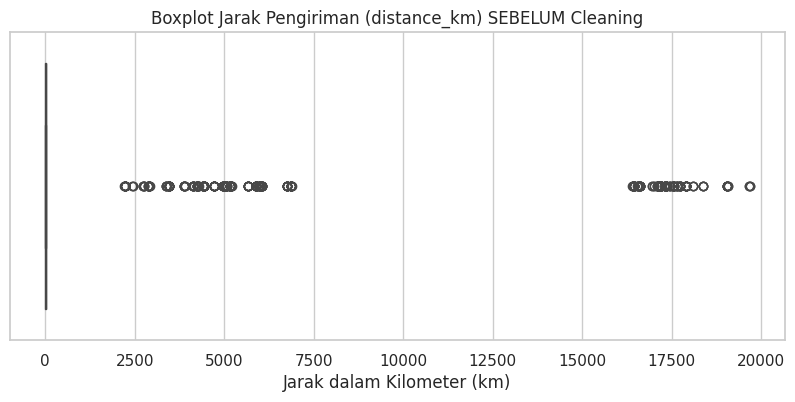

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visualisasi
sns.set_theme(style="whitegrid")

# Membuat plot untuk melihat sebaran data jarak SEBELUM dibersihkan
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['distance_km'], color='crimson')
plt.title('Boxplot Jarak Pengiriman (distance_km) SEBELUM Cleaning')
plt.xlabel('Jarak dalam Kilometer (km)')
plt.show()

In [ ]:
# Menampilkan 10 data dengan nilai 'distance_km' tertinggi
top_10_highest_distance = df.nlargest(10, 'distance_km')

# Tampilkan kolom ID, koordinat, dan jaraknya untuk melihat anomalinya
top_10_highest_distance[[
    'ID',
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude',
    'distance_km'
]]

,ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km
33524,0xbf01,-22.533662,-88.366217,22.663662,88.496217,19680.310661
6779,0xc014,-22.552672,-88.352885,22.662672,88.462885,19675.640276
2475,0xbf10,-22.538999,-88.322337,22.668999,88.452337,19671.329257
18817,0xc012,-22.537960,-88.349843,22.547960,88.359843,19664.826334
9526,0x3ef,-23.374989,-85.335486,23.444989,85.405486,19058.434851
753,0x462,-23.359194,-85.325447,23.449194,85.415447,19058.364625
35526,0x509,-23.369746,-85.339820,23.419746,85.389820,19057.186472
22282,0x3ed,-23.351058,-85.325731,23.421058,85.395731,19056.275060
30624,0x481,-23.357804,-85.325146,23.417804,85.385146,19055.157347
43445,0x4d7,-23.351058,-85.325731,23.401058,85.375731,19054.180156


In [ ]:
# 1. Menghitung jumlah data yang jaraknya > 30 km (dianggap tidak wajar untuk delivery makanan)
anomalous_data = df[df['distance_km'] > 30]
total_anomali = len(anomalous_data)
total_seluruh_data = len(df)
persentase_anomali = (total_anomali / total_seluruh_data) * 100

print(f"Total data tidak wajar (> 30 km): {total_anomali} baris")
print(f"Persentase dari seluruh dataset: {persentase_anomali:.2f}%")

# 2. Mengintip statistik koordinat pada data yang anomali tersebut
print("\n--- Ringkasan Koordinat pada Data Anomali ---")
print(anomalous_data[[
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude'
]].describe().loc[['min', 'max']])

Total data tidak wajar (> 30 km): 431 baris
Persentase dari seluruh dataset: 0.95%

--- Ringkasan Koordinat pada Data Anomali ---
     Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
min           -30.905562            -88.366217                    9.969778   
max            -9.959778             88.433452                   31.045562   

     Delivery_location_longitude  
min                    72.788666  
max                    88.523452  


karena hanya 0.95% dari total data, maka diputuskan untuk hapus data outlier

In [ ]:
# 1. Filter hanya data dengan jarak yang masuk akal (0 - 30 km)
# Kolom rating juga kita batasi maksimal 5.0 karena ada anomali rating 6.0 tadi
df_final = df[(df['distance_km'] > 0) & (df['distance_km'] <= 30)].copy()
df_final = df_final[df_final['Delivery_person_Ratings'] <= 5.0]

# 2. Cek ukuran data akhir
print(f"Jumlah baris data setelah dibersihkan total: {len(df_final)} baris")

Jumlah baris data setelah dibersihkan total: 45122 baris


In [ ]:
#cek akhir
print("--- STATISTIK DESKRIPTIF ---")
print(df[['Time_taken (min)', 'distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings']].describe())
df_final.info()

--- STATISTIK DESKRIPTIF ---
       Time_taken (min)   distance_km  Delivery_person_Age  \
count      45584.000000  45584.000000         45584.000000   
mean          26.293963     99.258962            29.584525   
std            9.384298   1099.148610             5.696221   
min           10.000000      1.464148            15.000000   
25%           19.000000      4.660565            25.000000   
50%           26.000000      9.258540            30.000000   
75%           32.000000     13.755336            34.000000   
max           54.000000  19680.310661            50.000000   

       Delivery_person_Ratings  
count             45584.000000  
mean                  4.636546  
std                   0.327931  
min                   1.000000  
25%                   4.600000  
50%                   4.700000  
75%                   4.800000  
max                   6.000000  
<class 'pandas.core.frame.DataFrame'>
Index: 45122 entries, 0 to 45583
Data columns (total 21 columns):
 #   Column

In [ ]:
# 3. Export ke CSV
df_final.to_csv('Zomato_Final_Cleaned.csv', index=False)
print("File 'Zomato_Final_Cleaned.csv' berhasil dibuat!")

File 'Zomato_Final_Cleaned.csv' berhasil dibuat!


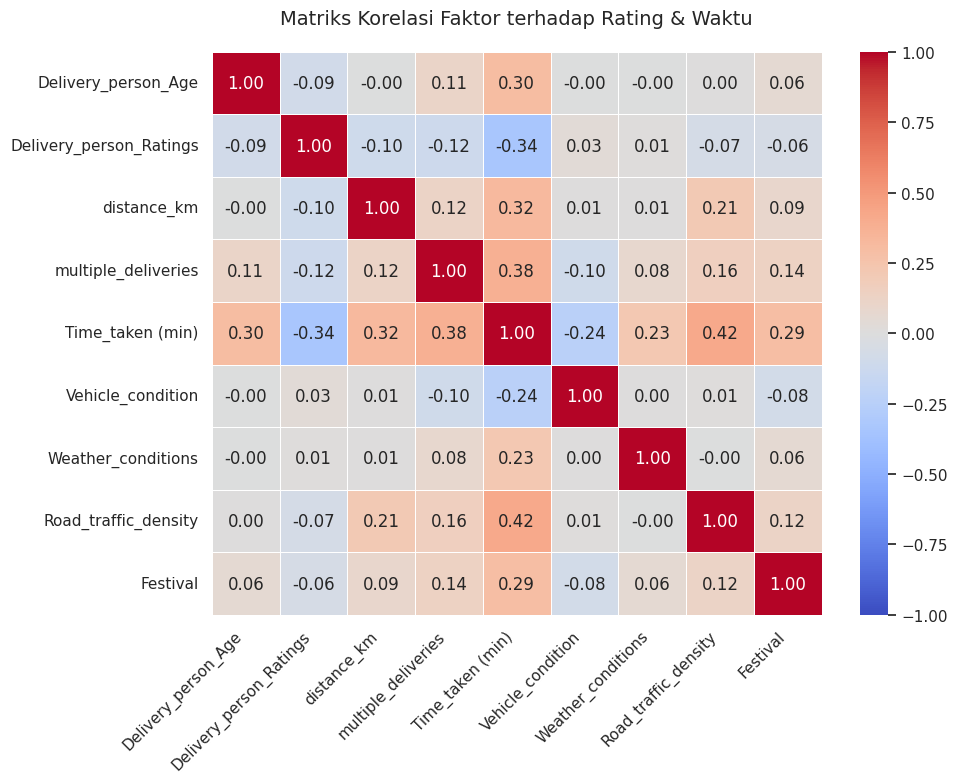

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ambil hanya kolom-kolom yang mau kita cek korelasinya dari df_final
kolom_analisis = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "distance_km",
    "multiple_deliveries",
    "Time_taken (min)",
    "Vehicle_condition",
    "Weather_conditions",
    "Road_traffic_density",
    "Festival",
]

# Potong dataframe agar hanya berisi kolom yang dipilih
# Gunakan df_final yang sudah kamu bersihkan sebelumnya
df_clean = df_final[kolom_analisis].copy()

# 2. Encoding: Mengubah data teks/kategori menjadi angka agar bisa dihitung statistiknya
weather_dict = {
    "Sunny": 1,
    "Windy": 2,
    "Stormy": 3,
    "Sandstorms": 4,
    "Fog": 5,
    "Cloudy": 6,
}
df_clean["Weather_conditions"] = df_clean["Weather_conditions"].map(
    weather_dict
)

traffic_dict = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
df_clean["Road_traffic_density"] = df_clean["Road_traffic_density"].map(
    traffic_dict
)

festival_dict = {"No": 0, "Yes": 1}
df_clean["Festival"] = df_clean["Festival"].map(festival_dict)

# 3. Hitung Korelasi Pearson
corr_matrix = df_clean.corr(method="pearson")

# 4. Gambar Heatmap Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Matriks Korelasi Faktor terhadap Rating & Waktu", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Tampilkan grafik
plt.show()

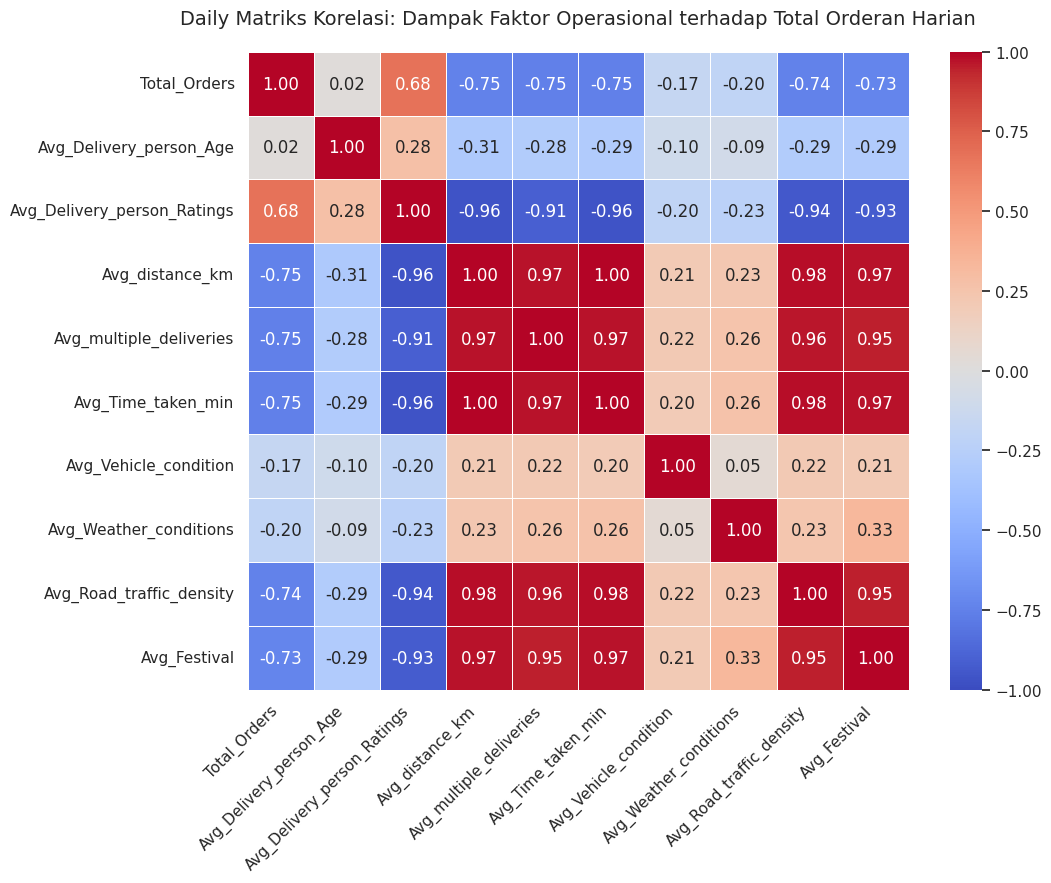

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Tahap Encoding Teks ke Angka (Sesuai codingan kamu kemarin)
# -------------------------------------------------------------
df_clean = df_final.copy()

# Pastikan format tanggal sudah benar agar bisa di-grouping per hari
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'])

weather_dict = {"Sunny": 1, "Windy": 2, "Stormy": 3, "Sandstorms": 4, "Fog": 5, "Cloudy": 6}
df_clean["Weather_conditions"] = df_clean["Weather_conditions"].map(weather_dict)

traffic_dict = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
df_clean["Road_traffic_density"] = df_clean["Road_traffic_density"].map(traffic_dict)

festival_dict = {"No": 0, "Yes": 1}
df_clean["Festival"] = df_clean["Festival"].map(festival_dict)


# -------------------------------------------------------------
# 2. Proses Agregasi ke Tingkat Harian (Daily Level Dataset)
# -------------------------------------------------------------
# Di sini kita kelompokkan data berdasarkan Order_Date
daily_df = df_clean.groupby('Order_Date').agg(
    Total_Orders=('ID', 'count'), # Menghitung total order per hari (kunci utama hipotesis kamu!)
    Avg_Delivery_person_Age=('Delivery_person_Age', 'mean'),
    Avg_Delivery_person_Ratings=('Delivery_person_Ratings', 'mean'),
    Avg_distance_km=('distance_km', 'mean'),
    Avg_multiple_deliveries=('multiple_deliveries', 'mean'),
    Avg_Time_taken_min=('Time_taken (min)', 'mean'),
    Avg_Vehicle_condition=('Vehicle_condition', 'mean'),
    Avg_Weather_conditions=('Weather_conditions', 'mean'),   # Rata-rata indeks cuaca harian
    Avg_Road_traffic_density=('Road_traffic_density', 'mean'), # Rata-rata tingkat kemacetan harian
    Avg_Festival=('Festival', 'mean')                         # Proporsi hari festival
).reset_index()


# -------------------------------------------------------------
# 3. Hitung Korelasi Pearson Tingkat Harian
# -------------------------------------------------------------
# Kita buang kolom 'Order_Date' karena bertipe tanggal, lalu hitung korelasi antar angka
corr_matrix_daily = daily_df.drop(columns=['Order_Date']).corr(method='pearson')


# -------------------------------------------------------------
# 4. Gambar Heatmap Korelasi Baru
# -------------------------------------------------------------
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix_daily,
    annot=True,
    fmt=".2f",
    cmap="coolwarm", # Biru = Negatif, Merah = Positif
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Daily Matriks Korelasi: Dampak Faktor Operasional terhadap Total Orderan Harian", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Tampilkan grafik di Google Colab
plt.show()

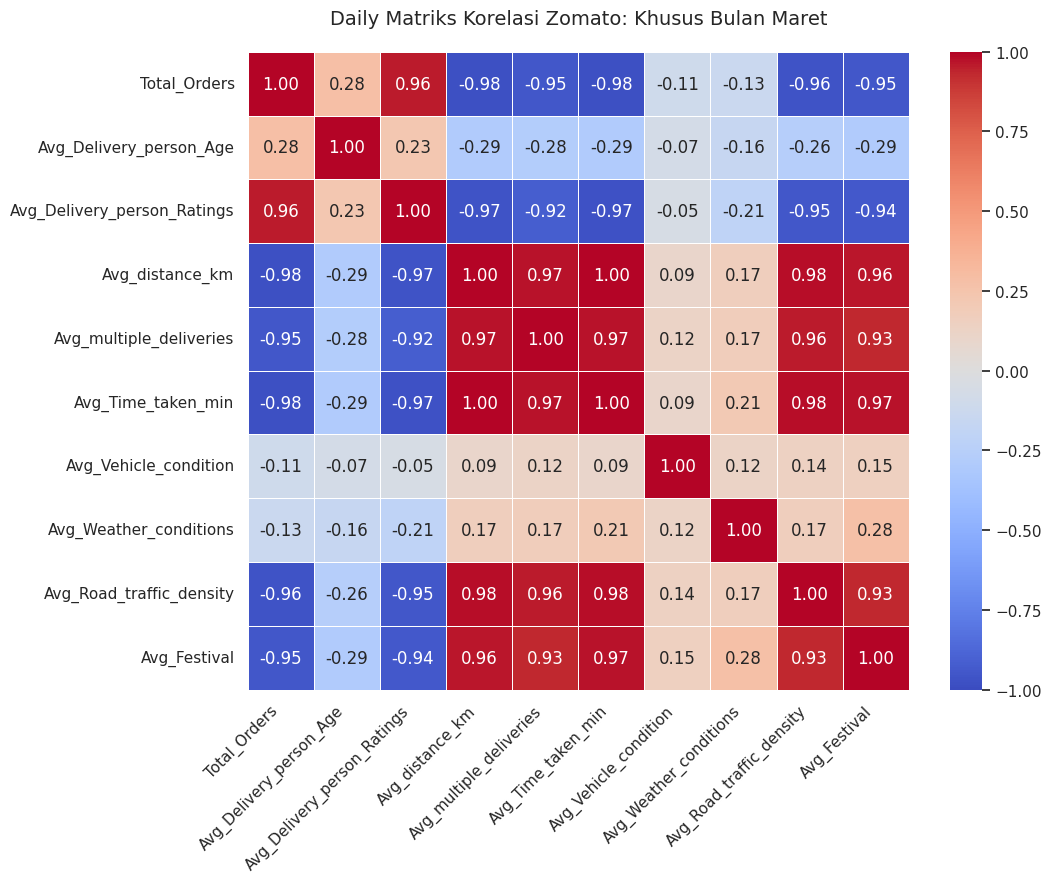

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Tahap Copy Data & Format Tanggal
# -------------------------------------------------------------
df_clean = df_final.copy()
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'])

# -------------------------------------------------------------
# 2. FILTER KHUSUS BULAN MARET (Kunci Perbaikan Kamu)
# -------------------------------------------------------------
# dt.month == 3 artinya kita hanya mengambil data bulan Maret saja
df_maret = df_clean[df_clean['Order_Date'].dt.month == 3].copy()

# -------------------------------------------------------------
# 3. Encoding Teks ke Angka (Sesuai parameter kemarin)
# -------------------------------------------------------------
weather_dict = {"Sunny": 1, "Windy": 2, "Stormy": 3, "Sandstorms": 4, "Fog": 5, "Cloudy": 6}
df_maret["Weather_conditions"] = df_maret["Weather_conditions"].map(weather_dict)

traffic_dict = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
df_maret["Road_traffic_density"] = df_maret["Road_traffic_density"].map(traffic_dict)

festival_dict = {"No": 0, "Yes": 1}
df_maret["Festival"] = df_maret["Festival"].map(festival_dict)

# -------------------------------------------------------------
# 4. Proses Agregasi ke Tingkat Harian (Khusus Maret)
# -------------------------------------------------------------
daily_maret = df_maret.groupby('Order_Date').agg(
    Total_Orders=('ID', 'count'),
    Avg_Delivery_person_Age=('Delivery_person_Age', 'mean'),
    Avg_Delivery_person_Ratings=('Delivery_person_Ratings', 'mean'),
    Avg_distance_km=('distance_km', 'mean'),
    Avg_multiple_deliveries=('multiple_deliveries', 'mean'),
    Avg_Time_taken_min=('Time_taken (min)', 'mean'),
    Avg_Vehicle_condition=('Vehicle_condition', 'mean'),
    Avg_Weather_conditions=('Weather_conditions', 'mean'),
    Avg_Road_traffic_density=('Road_traffic_density', 'mean'),
    Avg_Festival=('Festival', 'mean')
).reset_index()

# -------------------------------------------------------------
# 5. Hitung Korelasi Pearson Tingkat Harian
# -------------------------------------------------------------
corr_matrix_maret = daily_maret.drop(columns=['Order_Date']).corr(method='pearson')

# -------------------------------------------------------------
# 6. Tampilkan Heatmap Korelasi Baru
# -------------------------------------------------------------
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix_maret,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Daily Matriks Korelasi Zomato: Khusus Bulan Maret", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Tampilkan di Colab
plt.show()